# 2.3 Fleet size

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Relocations as a function of fleet size

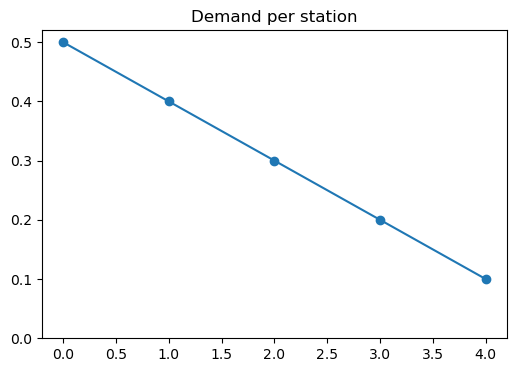

In [3]:
# Calculate a dependency curve

scenario = 'few_stations'

if scenario == 'few_stations':
    n_stations = 5
    n_levels = 5 # How many levels of demand are there
    default_demand = 0.5 # Order frequency, betweeen 0 and 1. 
                          # If too low, many runs are wasted. If too high, it's no longer a poisson-like process.
    demand_levels = np.arange(n_levels, 0, -1)/n_levels * default_demand
    n_cars = 20
elif scenario == 'suburbs': # Center and suburbs
    n_stations = 10
    n_levels = 10
    demand_levels = np.array(list(np.arange(0.5, 0.25, -0.05)) + list(np.arange(0.3, 0.2, -0.02)/10))    
    n_cars = 5
else:
    raise ValueError("Unknown scenario")
       
n_steps_preparation = 50000 # For how many steps stats are NOT collected
n_steps_per_experiment = 2000
n_experiments = 100

n_cars_levels = [1, 2, 5, 7, 10, 15, 20, 30, 40]

demand = (list(demand_levels)*int(np.ceil(n_stations / n_levels)))[:n_stations] # Circular sampling, if needed

cm1_per_trip = 5
relo_cost = 20
car_cost_per_day = 20
ticks_per_day = 20/max(demand) # Assuming 20 trips/day from the hottest zone

plt.figure(figsize=(6,4)) # Visualize demand, to be sure
plt.plot(demand, 'o-')
plt.ylim(0, None)
plt.title("Demand per station");
#print("Demand values to be used:", [np.round(x, 3) for x in demand])

In [4]:
# Main loop, but now only performing (and counting) profitable relocations

def run_model_smart(n_experiments, n_steps_per_experiment, n_steps_preparation, demand, n_cars):
    # Set rentals_per_relocation to 0 to not have any relocations
    
    n_stations = len(demand)
    n_steps =  n_steps_per_experiment*n_experiments + n_steps_preparation
    
    cm1 = np.zeros(shape=(n_experiments, n_stations)) # An average of departing and arriving rentals
    average_cars = np.zeros(shape=(n_experiments, n_stations))
    total_attempts = np.zeros(shape=(n_experiments, n_stations)) # Demand
    total_rentals = np.zeros(shape=(n_experiments, n_stations))
    total_relos = np.zeros(shape=(n_experiments, n_stations))
    
    departures_counter = 0 # To calculate rolling average rentals per tick
    
    state_history = np.zeros(shape=(n_steps_per_experiment, n_stations)) # Will only remember one run

    state = np.array([n_cars // n_stations]*n_stations) # Case of cars being distributed uniformly
    state[0] = n_cars - state[1:].sum() # Only needed for uniform cas (to make sure n_cars is right)    

    for i_step in range(n_steps):        
        attempts = (np.random.uniform(size=n_stations) < demand) # If a car was ordered
        departures = attempts * (state > 0)
        destinations = np.random.choice(n_stations, size=n_stations, p=demand/sum(demand))
        
        if (i_step >= n_steps_preparation) & ((i_step - n_steps_preparation) % n_steps_per_experiment == 0):
            i_experiment = (i_step - n_steps_preparation) // n_steps_per_experiment
            print('.', end='') # Experiment counter

        destinations[~departures] = -1 # If the car didn't leave then it doesn't arrive anywhere
        arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

        state = state - departures + arrivals
        
        departures_counter += departures.sum()
        rentals_per_tick = departures_counter / max(1, i_step)
        #plt.plot(i_step, rentals_per_tick, 'k.', markersize=1) # Troubleshooting plot

        # Relocation (now on every tick)
        relo_happened = False
        if i_step > n_steps_preparation: # Don't try to relocate before we know rentals_per_tick
            demand_per_car = demand/state.clip(1,None) # Before relo demand
            bad_zone_demand = demand_per_car[state>0].min()
            start_relo = np.where((demand_per_car == bad_zone_demand) & (state > 0))[0][0]
            demand_per_car = demand/(1+state.clip(1, None)) # After relo demand
            good_zone_demand = demand_per_car.max()
            end_relo = np.where(demand_per_car == good_zone_demand)[0][0]
            relo_impact = (
                rentals_per_tick * cm1_per_trip / n_cars * (1/bad_zone_demand - 1/good_zone_demand) 
                - relo_cost
            )
            if relo_impact > 0: # If profitable, do a relocation
                relo_happened = True        
                state[start_relo] -= 1
                state[end_relo] += 1            

        if i_step > n_steps_preparation: # Collect stats
            cm1[i_experiment, :] += (departures + arrivals)/2/n_steps_per_experiment
            # We divide rentals by 2 for the sum across all cm1 to be true (not double-counted)
            average_cars[i_experiment, :] += state/n_steps_per_experiment
            total_attempts[i_experiment, :] += attempts*1            
            total_rentals[i_experiment, :] += departures
            if relo_happened:
                total_relos[i_experiment, start_relo] += 1

            if (n_steps - i_step) < n_steps_per_experiment: # Last run            
                state_history[(i_step - n_steps_preparation) % n_steps_per_experiment, :] = state
               
    print("\nFinal rentals_per_tick:", rentals_per_tick)
    return cm1, average_cars, total_attempts, total_rentals, total_relos, state_history
        
# Test
print("Demand values to be used:", [np.round(x, 3) for x in demand])
cm1, average_cars, total_attempts, total_rentals, total_relos, state_history = \
    run_model_smart(n_experiments=10, n_steps_per_experiment=2000,
                    n_steps_preparation=50000, demand=demand, n_cars=20)

print("Total relocations:", total_relos.sum())
print("Relocation frequency:", total_relos.sum()/(n_steps_per_experiment*n_experiments))

Demand values to be used: [0.5, 0.4, 0.3, 0.2, 0.1]
..........
Final rentals_per_tick: 1.295489935570508
Total relocations: 160.0
Relocation frequency: 0.0008


In [5]:
# Run the experiments
memory_n_relos = np.zeros(shape=(n_experiments, len(n_cars_levels)))
memory_cm2 = np.zeros(shape=(n_experiments, len(n_cars_levels)))
for i, n_cars in enumerate(n_cars_levels):
    print(f"N cars: {n_cars}")
    cm1, average_cars, total_attempts, total_rentals, total_relos, state_history = \
    run_model_smart(n_experiments=n_experiments, n_steps_per_experiment=n_steps_per_experiment,
                    n_steps_preparation=n_steps_preparation, demand=demand, n_cars=n_cars)
    
    memory_n_relos[:, i] = total_relos.sum(axis=1)/n_steps_per_experiment
    memory_cm2[:, i] = (
        (total_rentals.sum(axis=1)*cm1_per_trip - total_relos.sum(axis=1)*relo_cost)/n_steps_per_experiment
        - n_cars * car_cost_per_day / ticks_per_day
    )

print("Done")

N cars: 1
....................................................................................................
Final rentals_per_tick: 0.29847719390877564
N cars: 2
....................................................................................................
Final rentals_per_tick: 0.5340901363605455
N cars: 5
....................................................................................................
Final rentals_per_tick: 0.8950715802863212
N cars: 7
....................................................................................................
Final rentals_per_tick: 1.0153560614242456
N cars: 10
....................................................................................................
Final rentals_per_tick: 1.14811259245037
N cars: 15
....................................................................................................
Final rentals_per_tick: 1.2509530038120154
N cars: 20
................................................................

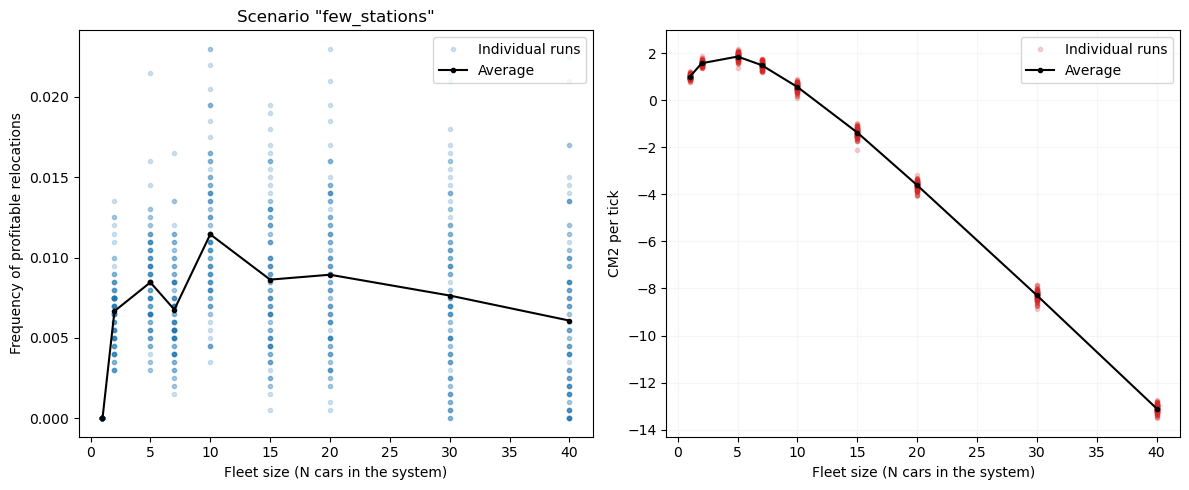

In [6]:
# Visualize
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(list(n_cars_levels)*n_experiments, memory_n_relos.flatten(), 
         '.', color="tab:blue", alpha=0.2, label="Individual runs")
plt.plot(n_cars_levels, memory_n_relos.mean(axis=0), 'k.-', label="Average")
plt.xlabel("Fleet size (N cars in the system)")
plt.ylabel("Frequency of profitable relocations");
plt.title(f"Scenario \"{scenario}\"")
plt.legend(loc="upper right")

plt.subplot(122)
plt.plot(list(n_cars_levels)*n_experiments, memory_cm2.flatten(), 
         '.', color="tab:red", alpha=0.2, label="Individual runs")
plt.plot(n_cars_levels, memory_cm2.mean(axis=0), 'k.-', label="Average")
plt.xlabel("Fleet size (N cars in the system)")
plt.ylabel("CM2 per tick");
plt.grid(alpha=0.1)
plt.legend(loc="upper right")

plt.tight_layout()

plt.savefig(f"../figures02relos_02stations_04fleet_size_{scenario}.svg", dpi=300)